# WM Lindblad evolution

In [8]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import dynamiqs as dq

jax.config.update("jax_enable_x64", True)

In [9]:
# Parameters
gamma_E = 1e-3   # Error rate
gamma_C = 1   # Correction rate
lam = 0.0
T = 10.0
ntsave = 201

# 3-qubit Paulis
X1 = dq.tensor(dq.sigmax(), dq.eye(2), dq.eye(2))
X2 = dq.tensor(dq.eye(2), dq.sigmax(), dq.eye(2))
X3 = dq.tensor(dq.eye(2), dq.eye(2), dq.sigmax())
Id = dq.tensor(dq.eye(2), dq.eye(2), dq.eye(2))

# Codespace projector P_C = |000><000| + |111><111|
ket000 = dq.tensor(dq.basis(2, 0), dq.basis(2, 0), dq.basis(2, 0))
ket111 = dq.tensor(dq.basis(2, 1), dq.basis(2, 1), dq.basis(2, 1))

P_C = ket000.proj() + ket111.proj()
P_codeword = ket000.proj()


def J(R, gamma_C, lam):
    """Correction jump: sqrt(gamma_C) P_C R + lam R P_C R."""
    return jnp.sqrt(gamma_C) * (P_C @ R + lam * R @ P_C @ R)

# Error dissipators L_i^E = sqrt(gamma_E) X_i
# Correction dissipators J_s for R_s in {I, X1, X2, X3}
jump_ops = [
    jnp.sqrt(gamma_E) * X1,
    jnp.sqrt(gamma_E) * X2,
    jnp.sqrt(gamma_E) * X3,
    J(Id, gamma_C, lam),   # s = (0, 0)
    J(X1, gamma_C, lam),   # s = (1, 0)
    J(X2, gamma_C, lam),   # s = (1, 1)
    J(X3, gamma_C, lam),   # s = (0, 1)
]

H = 0 * Id
psi0 = ket000
tsave = jnp.linspace(0.0, T, ntsave)

In [10]:
#result = dq.mesolve(H, jump_ops, psi0, tsave, exp_ops=[P_C])
result = dq.mesolve(H, jump_ops, psi0, tsave, exp_ops=[P_codeword])

|██████████| 100.0% ◆ elapsed 2.62ms ◆ remaining 0.00ms


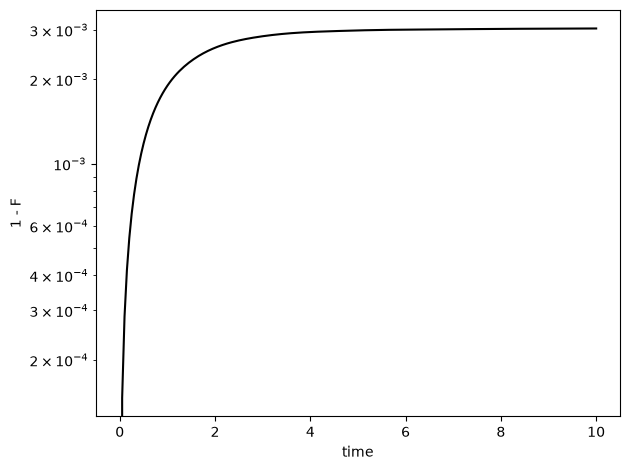

In [11]:
F = jnp.real(result.expects[0])

plt.figure()
plt.semilogy(tsave, 1.0 - jnp.abs(F), "k")
plt.xlabel("time")
plt.ylabel("1 - F")
plt.tight_layout()
plt.show()

|██████████| 100.0% ◆ elapsed 1.92ms ◆ remaining 0.00ms


|██████████| 100.0% ◆ elapsed 1.83ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 3.18ms ◆ remaining 0.00ms


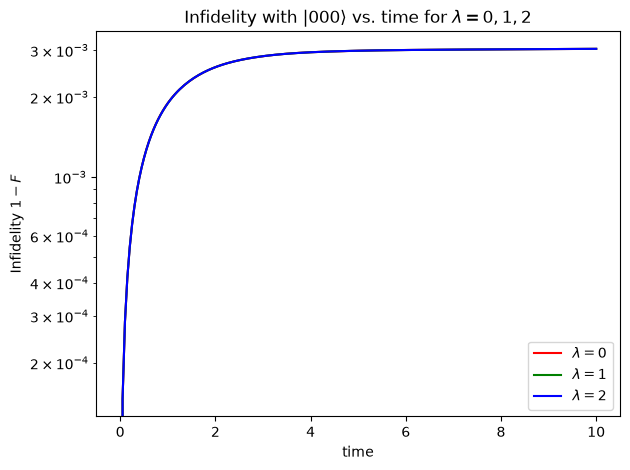

In [12]:
# Show the 3 curves of infidelities (1 - F) with the initial codeword for lam = 0, 1, 2
lams = [0, 1, 2]
colors = ["r", "g", "b"]
labels = [r"$\lambda=0$", r"$\lambda=1$", r"$\lambda=2$"]

plt.figure()
for lam, color, label in zip(lams, colors, labels):
    jump_ops = [
        jnp.sqrt(gamma_E) * X1,
        jnp.sqrt(gamma_E) * X2,
        jnp.sqrt(gamma_E) * X3,
        J(Id, gamma_C, lam),
        J(X1, gamma_C, lam),
        J(X2, gamma_C, lam),
        J(X3, gamma_C, lam)
       ]
    # Evolve and measure infidelity with |000>
    result = dq.mesolve(H, jump_ops, psi0, tsave, exp_ops=[P_codeword])
    F = jnp.real(result.expects[0])
    plt.semilogy(tsave, 1.0 - jnp.abs(F), color, label=label)

plt.xlabel("time")
plt.ylabel(r"Infidelity $1 - F$")
plt.title(r"Infidelity with $|000\rangle$ vs. time for $\lambda = 0, 1, 2$")
plt.legend()
plt.tight_layout()
plt.show()

|██████████| 100.0% ◆ elapsed 1.39ms ◆ remaining 0.00ms


|██████████| 100.0% ◆ elapsed 1.70ms ◆ remaining 0.00ms


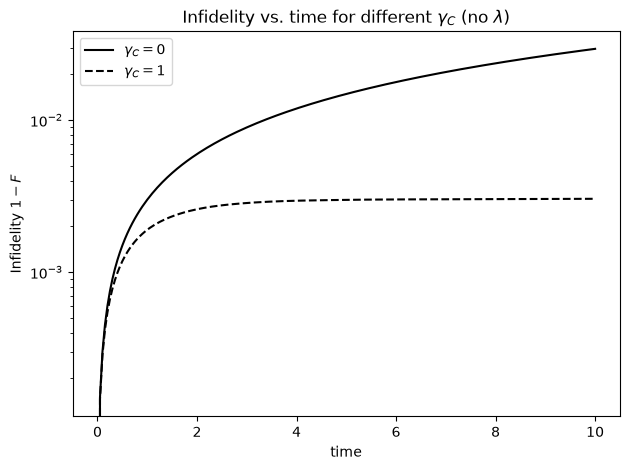

In [14]:
gamma_E = 1e-3
gamma_C_set = [0, 1]
linestyles = ["-", "--"]  # solid for gamma_C=0, dashed for gamma_C=1
color = "k"  # single color since there's only one curve per gamma_C
label_base = r"$\gamma_C={}$"

plt.figure()
for gamma_C, linestyle in zip(gamma_C_set, linestyles):
    
    jump_ops = [
        jnp.sqrt(gamma_E) * X1,
        jnp.sqrt(gamma_E) * X2,
        jnp.sqrt(gamma_E) * X3,
        J(X1, gamma_C, 0),
        J(X2, gamma_C, 0),
        J(X3, gamma_C, 0)
   
    ]
    result = dq.mesolve(H, jump_ops, psi0, tsave, exp_ops=[P_codeword])
    F = jnp.real(result.expects[0])
    plt.semilogy(tsave, 1.0 - jnp.abs(F), color=color, linestyle=linestyle, label=label_base.format(gamma_C))

plt.xlabel("time")
plt.ylabel("Infidelity $1-F$")
plt.title(r"Infidelity vs. time for different $\gamma_C$ (no $\lambda$)")
plt.legend()
plt.tight_layout()
plt.show()

|██████████| 100.0% ◆ elapsed 2.85ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 1.81ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 3.23ms ◆ remaining 0.00ms


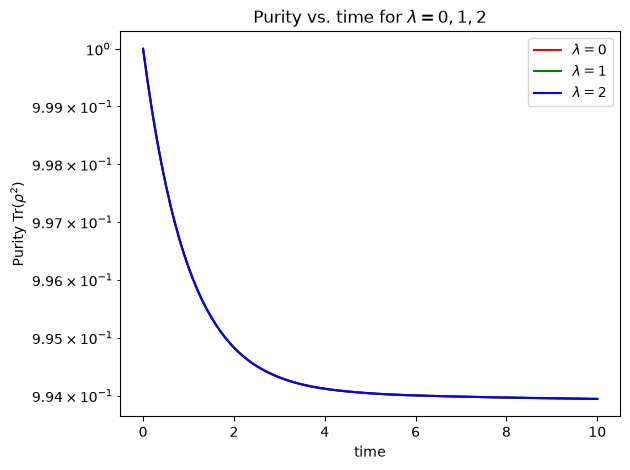

In [17]:
gamma_E = 1e-3   # Error rate
gamma_C = 1   # Correction rate
T = 10.0
ntsave = 201

# To check consistency, ensure J is defined in this cell and picks up lam:
lams = [0, 1, 2]
colors = ["r", "g", "b"]
labels = [r"$\lambda=0$", r"$\lambda=1$", r"$\lambda=2$"]

import numpy as np  # Needed for fallback conversion

plt.figure()
for lam, color, label in zip(lams, colors, labels):
    # Construct jump_ops using current lam value in J
    jump_ops = [
        jnp.sqrt(gamma_E) * X1,
        jnp.sqrt(gamma_E) * X2,
        jnp.sqrt(gamma_E) * X3,
        J(Id, gamma_C, lam),
        J(X1, gamma_C, lam),
        J(X2, gamma_C, lam),
        J(X3, gamma_C, lam)
    ]
    # Evolve and compute full density matrices at each time
    result = dq.mesolve(H, jump_ops, psi0, tsave)
    purity = []
    # Loop over result.states to compute purity at each time step
    for rho in result.states:
        # Convert rho to numpy array if needed, handling dynamiqs DenseQArray or other types
        if hasattr(rho, 'toarray'):
            arr = rho.toarray()
        elif hasattr(rho, 'numpy'):
            arr = rho.numpy()
        else:
            arr = np.asarray(rho)  # Fallback to numpy's asarray
        purity.append(jnp.real(jnp.trace(arr @ arr)))
    plt.semilogy(tsave, purity, color, label=label)

plt.xlabel("time")
plt.ylabel(r"Purity $\mathrm{Tr}(\rho^2)$")
plt.title(r"Purity vs. time for $\lambda = 0, 1, 2$")
plt.legend()
plt.tight_layout()
plt.show()

# λ-sensitive diagnostics

Current jumps (including the identity syndrome):

$$
J_s=\sqrt{\gamma_C}\,(P_C R_s+\lambda\,R_s P_C R_s),\qquad R_s\in\{I,X_1,X_2,X_3\}.
$$

Codespace / codeword populations do not depend on $\lambda$. Difference shows up in code–error coherences and in mixedness $1-\mathrm{Tr}(\rho^2)$, especially starting from an error state.

In [22]:
def jump_ops_lam(lam, gamma_E=gamma_E, gamma_C=gamma_C):
    """Same construction as the setup cell, with an explicit lambda."""
    return [
        jnp.sqrt(gamma_E) * X1,
        jnp.sqrt(gamma_E) * X2,
        jnp.sqrt(gamma_E) * X3,
        J(Id, gamma_C, lam),
        J(X1, gamma_C, lam),
        J(X2, gamma_C, lam),
        J(X3, gamma_C, lam),
    ]


ket100 = dq.tensor(dq.basis(2, 1), dq.basis(2, 0), dq.basis(2, 0))
O_coh = ket000 @ ket100.dag()  # Tr(O ρ) = ⟨100|ρ|000⟩

lams = [0.0, 1.0]
colors = ["C0", "C1"]
labels = [r"$\lambda=0$", r"$\lambda=1$"]

|██████████| 100.0% ◆ elapsed 7.16ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 1.89ms ◆ remaining 0.00ms


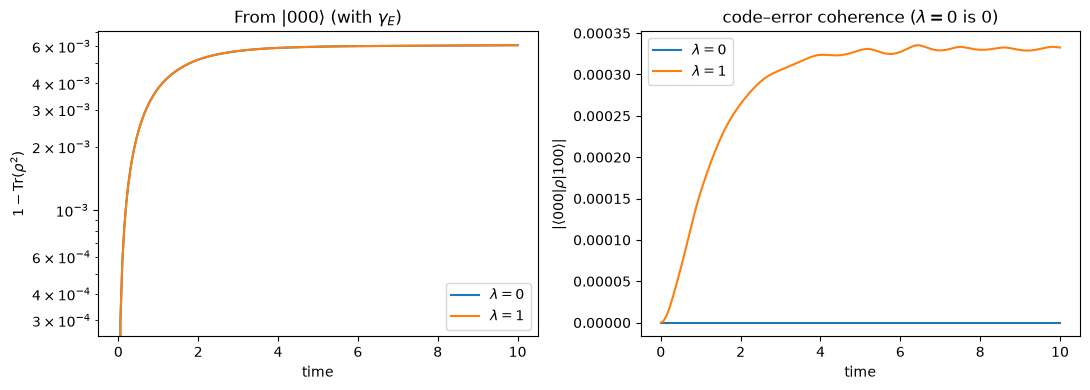

In [23]:
# From |000>: λ shows up in coherence; 1-purity split is tiny
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for lam, color, label in zip(lams, colors, labels):
    result = dq.mesolve(
        H, jump_ops_lam(lam), ket000, tsave, exp_ops=[O_coh]
    )
    purity = jnp.array([jnp.real(dq.purity(rho)) for rho in result.states])
    axes[0].semilogy(tsave, 1.0 - purity, color, label=label)
    axes[1].plot(tsave, jnp.abs(result.expects[0]), color, label=label)

axes[0].set_xlabel("time")
axes[0].set_ylabel(r"$1-\mathrm{Tr}(\rho^2)$")
axes[0].set_title(r"From $|000\rangle$ (with $\gamma_E$)")
axes[0].legend()
axes[1].set_xlabel("time")
axes[1].set_ylabel(r"$|\langle 000|\rho|100\rangle|$")
axes[1].set_title(r"code–error coherence ($\lambda=0$ is 0)")
axes[1].legend()
plt.tight_layout()
plt.show()

|██████████| 100.0% ◆ elapsed 1.73ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 2.00ms ◆ remaining 0.00ms


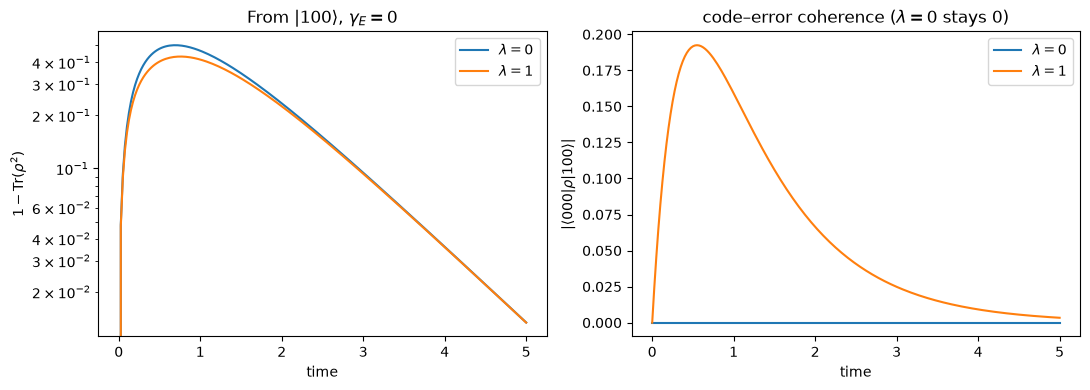

In [24]:
# From |100>, γ_E = 0: λ=0 vs λ=1 is visible in both panels
tsave_err = jnp.linspace(0.0, 5.0, 201)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for lam, color, label in zip(lams, colors, labels):
    result = dq.mesolve(
        H,
        jump_ops_lam(lam, gamma_E=0.0),
        ket100,
        tsave_err,
        exp_ops=[ket000.proj(), O_coh],
    )
    purity = jnp.array([jnp.real(dq.purity(rho)) for rho in result.states])
    axes[0].semilogy(tsave_err, 1.0 - purity, color, label=label)
    axes[1].plot(tsave_err, jnp.abs(result.expects[1]), color, label=label)

axes[0].set_xlabel("time")
axes[0].set_ylabel(r"$1-\mathrm{Tr}(\rho^2)$")
axes[0].set_title(r"From $|100\rangle$, $\gamma_E=0$")
axes[0].legend()
axes[1].set_xlabel("time")
axes[1].set_ylabel(r"$|\langle 000|\rho|100\rangle|$")
axes[1].set_title(r"code–error coherence ($\lambda=0$ stays 0)")
axes[1].legend()
plt.tight_layout()
plt.show()